# Quantum Fourier Transform

**Author:** Phabel Antonio López Delgado, BSc.

The Quantum Fourier Transform (QFT) is a fundamental building block of many quantum algorithms, including Shor's factoring algorithm and quantum phase estimation. It is the quantum analogue of the classical Discrete Fourier Transform and maps the computational basis to the Fourier basis.

In this notebook, we implement the QFT and its inverse from scratch (without using Qiskit's built‑in QFT) and verify that applying QFT followed by inverse QFT returns the original state. We test this on numbers 0 through 7 using 3 qubits.

**Key Concepts Covered:**
- Quantum Fourier Transform and its implementation.
- Inverse Quantum Fourier Transform.
- Phase gates and controlled rotations.
- Verification of QFT + inverse QFT = identity.

**Key Techniques & Libraries:**
- `qiskit` – quantum circuit construction.
- `qiskit-aer` – simulation backends.
- `matplotlib` – plotting histograms.

**Objective:**
To implement the QFT and inverse QFT from scratch and verify their correctness.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.circuit.library import CPhaseGate
from qiskit.visualization import plot_histogram
import random

# Configuration
CONFIG = {
    "shots": 1024,
    "n_qubits": 3,
    "random_seed": 42,
}

np.random.seed(CONFIG["random_seed"])
random.seed(CONFIG["random_seed"])

# Initialise simulator
qasm_sim = Aer.get_backend('qasm_simulator')

print("Configuration loaded.")
print(f"Simulator: {qasm_sim.name}")
print(f"Shots: {CONFIG['shots']}")
print(f"Number of qubits: {CONFIG['n_qubits']}")

Configuration loaded.
Simulator: qasm_simulator
Shots: 1024
Number of qubits: 3


## 1. Helper Functions

We define functions to encode a number into qubits and to plot the measurement results.

In [5]:
def encode_number(qc, qubits, number):
    """
    Encode a number into the qubits in binary representation.
    
    Args:
        qc: Quantum circuit.
        qubits: List of qubit indices.
        number: Integer to encode.
    """
    n = len(qubits)
    for i in range(n):
        if (number >> i) & 1:
            qc.x(qubits[i])

def plot_counts(counts, number, title_suffix='', save=False):
    """
    Plot a histogram of the measurement results.
    
    Args:
        counts: Dictionary of measurement counts.
        number: The input number (for the title).
        title_suffix: Additional text for the title.
        save: Whether to save the figure.
    """
    plt.figure(figsize=(8, 4))
    states = list(counts.keys())
    counts_vals = list(counts.values())
    plt.bar(states, counts_vals, color='skyblue', edgecolor='black')
    plt.xlabel('Bitstring result')
    plt.ylabel('Counts')
    plt.title(f'Results for input number {number} {title_suffix}')
    plt.tight_layout()
    if save:
        plt.savefig(f'qft_result_{number}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')

print("Helper functions defined.")

Helper functions defined.


## 2. Quantum Fourier Transform (Manual Implementation)

We implement the QFT and its inverse using only basic gates: Hadamard, controlled phase gates, and swaps.

In [6]:
def qft(qc, qubits):
    """
    Apply the Quantum Fourier Transform to the given qubits.
    
    Args:
        qc: Quantum circuit.
        qubits: List of qubit indices (assumed contiguous).
    """
    n = len(qubits)
    for i in range(n):
        qc.h(qubits[i])
        for j in range(i + 1, n):
            angle = np.pi / (2 ** (j - i))
            qc.append(CPhaseGate(angle), [qubits[j], qubits[i]])
    # Swap qubits to reverse order
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - i - 1])

def inverse_qft(qc, qubits):
    """
    Apply the inverse Quantum Fourier Transform to the given qubits.
    
    Args:
        qc: Quantum circuit.
        qubits: List of qubit indices (assumed contiguous).
    """
    n = len(qubits)
    # Swap qubits to reverse order
    for i in range(n // 2):
        qc.swap(qubits[i], qubits[n - i - 1])
    # Apply inverse QFT
    for i in reversed(range(n)):
        for j in reversed(range(i + 1, n)):
            angle = -np.pi / (2 ** (j - i))
            qc.append(CPhaseGate(angle), [qubits[j], qubits[i]])
        qc.h(qubits[i])

print("QFT and inverse QFT functions defined.")

QFT and inverse QFT functions defined.


## 3. Test QFT + Inverse QFT

We loop over numbers 0 to 7 (for 3 qubits), apply the QFT, then the inverse QFT, and measure. The results should match the original number, confirming that QFT followed by inverse QFT is identity.


Processing number: 0
Circuit drawing failed, falling back to text:
     ┌───┐                                                               »
q_0: ┤ H ├─■────────■───────────────────────────X──X─────────────────────»
     └───┘ │P(π/2)  │       ┌───┐               │  │                ┌───┐»
q_1: ──────■────────┼───────┤ H ├─■─────────────┼──┼───────■────────┤ H ├»
                    │P(π/4) └───┘ │P(π/2) ┌───┐ │  │ ┌───┐ │P(-π/2) └───┘»
q_2: ───────────────■─────────────■───────┤ H ├─X──X─┤ H ├─■─────────────»
                                          └───┘      └───┘               »
c: 3/════════════════════════════════════════════════════════════════════»
                                                                         »
«                         ┌───┐┌─┐
«q_0: ─■─────────■────────┤ H ├┤M├
«      │         │P(-π/2) └┬─┬┘└╥┘
«q_1: ─┼─────────■─────────┤M├──╫─
«      │P(-π/4)    ┌─┐     └╥┘  ║ 
«q_2: ─■───────────┤M├──────╫───╫─
«                  └╥┘      ║   ║ 
«c: 3/══════

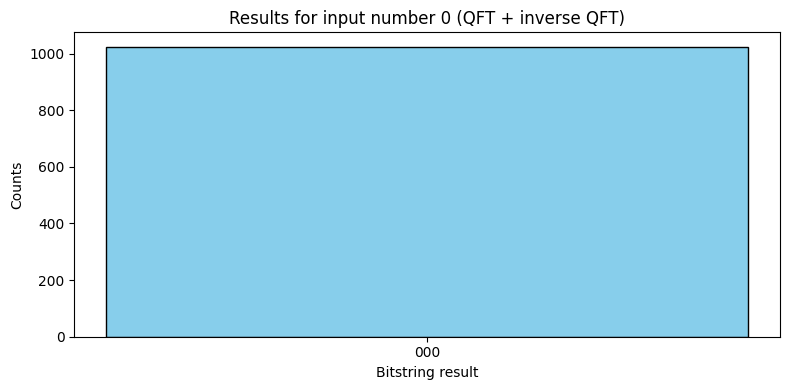


Processing number: 1
Results for number 1:
{'001': 1024}


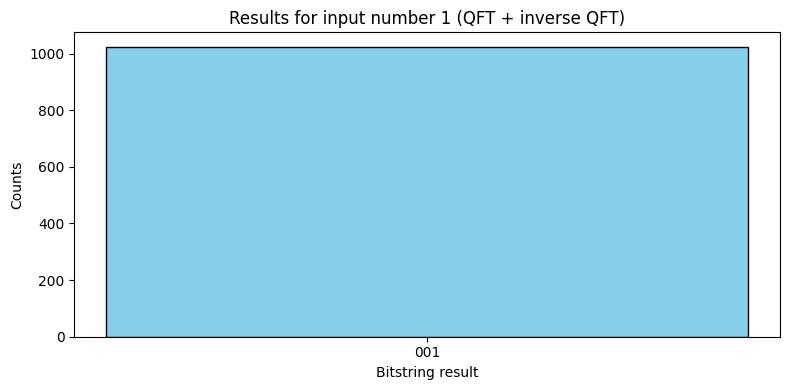


Processing number: 2
Results for number 2:
{'010': 1024}


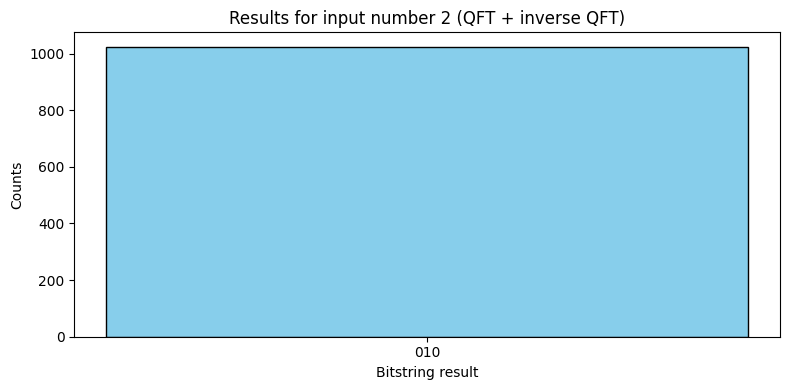


Processing number: 3
Results for number 3:
{'011': 1024}


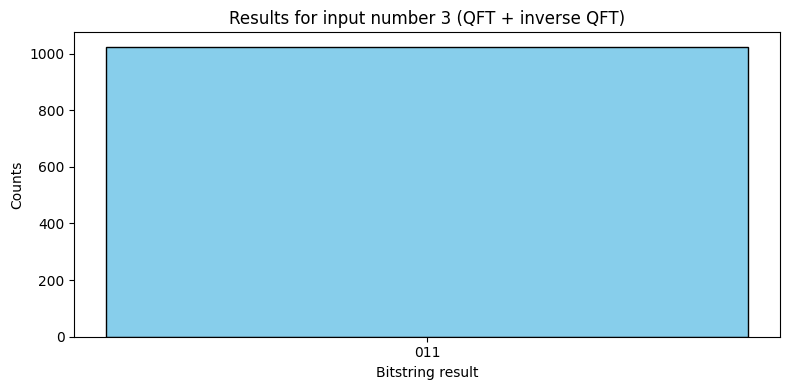


Processing number: 4
Results for number 4:
{'100': 1024}


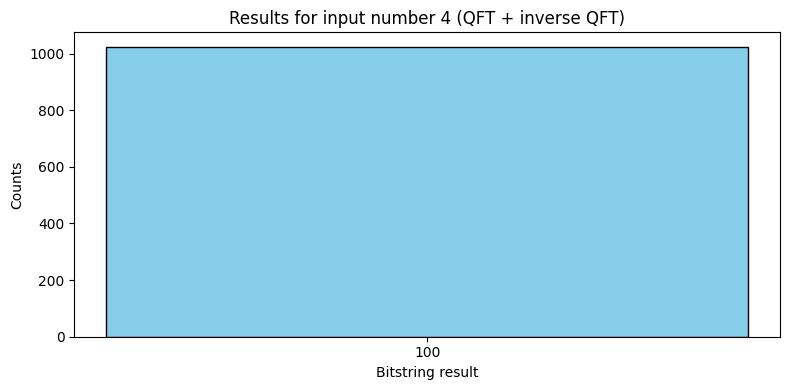


Processing number: 5
Results for number 5:
{'101': 1024}


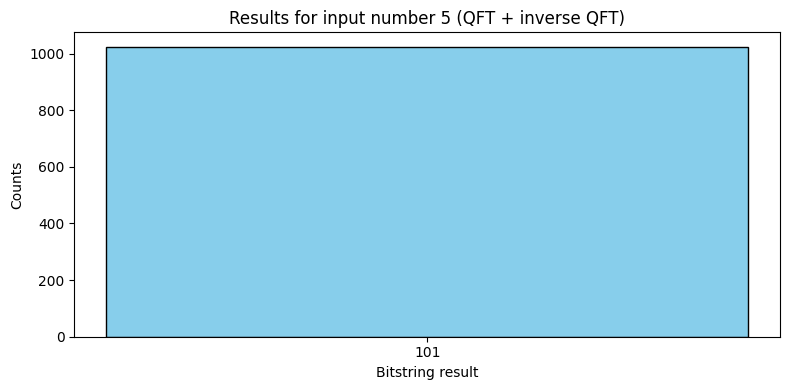


Processing number: 6
Results for number 6:
{'110': 1024}


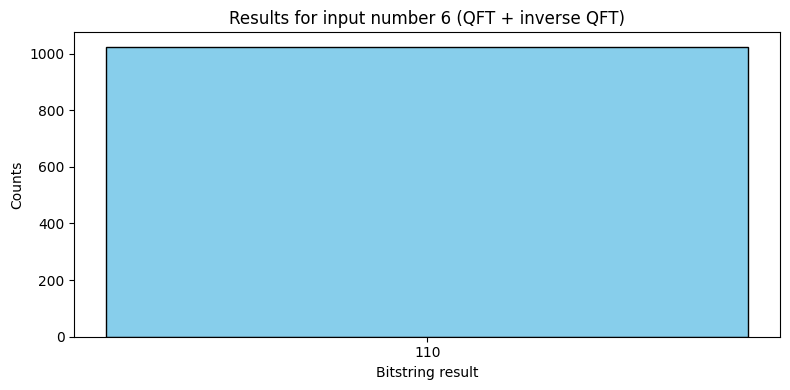


Processing number: 7
Results for number 7:
{'111': 1024}


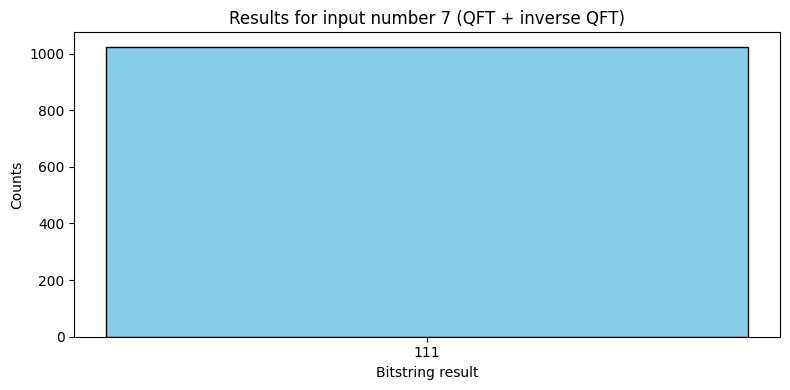

In [7]:
n_qubits = CONFIG["n_qubits"]
all_counts = {}

for number in range(8):
    print(f"\nProcessing number: {number}")
    
    # Create circuit
    qc = QuantumCircuit(n_qubits, n_qubits)
    qubits = range(n_qubits)
    
    # Encode the number
    encode_number(qc, qubits, number)
    
    # Apply QFT
    qft(qc, qubits)
    
    # Apply inverse QFT
    inverse_qft(qc, qubits)
    
    # Measure
    qc.measure(qubits, qubits)
    
    # Draw the circuit for the first number
    if number == 0:
        try:
            fig = qc.draw('mpl')
            fig.savefig('qft_circuit.png', dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)
        except Exception as e:
            print("Circuit drawing failed, falling back to text:")
            print(qc.draw(output='text'))
    
    # Simulate
    compiled = transpile(qc, qasm_sim)
    job = qasm_sim.run(compiled, shots=CONFIG["shots"])
    counts = job.result().get_counts()
    all_counts[number] = counts
    
    # Print results
    print(f"Results for number {number}:")
    print(counts)
    
    # Plot
    plot_counts(counts, number, title_suffix='(QFT + inverse QFT)', save=True)

## 4. Summary of Results

We compile the results for all numbers into a single table for easy comparison.

In [8]:
print("\n=== Summary of Results ===\n")
print(f"{'Input':^10} {'Output (most common)':^25} {'All results':^30}")
print("-" * 70)

for number in range(8):
    counts = all_counts[number]
    most_common = max(counts, key=counts.get)
    print(f"{number:^10} {most_common:^25} {str(counts):^30}")


=== Summary of Results ===

  Input      Output (most common)             All results          
----------------------------------------------------------------------
    0                 000                    {'000': 1024}         
    1                 001                    {'001': 1024}         
    2                 010                    {'010': 1024}         
    3                 011                    {'011': 1024}         
    4                 100                    {'100': 1024}         
    5                 101                    {'101': 1024}         
    6                 110                    {'110': 1024}         
    7                 111                    {'111': 1024}         


## 5. Analysis and Discussion

**Expected behaviour:**  
For each input number, applying the QFT followed by the inverse QFT should return the original number with high probability. The measurement histogram should show the original bitstring with overwhelming probability.

**Why does this work?**  
The QFT maps the computational basis to the Fourier basis. The inverse QFT performs the inverse transformation, recovering the original state. The circuit is unitary, so QFT × inverse QFT = identity.

**Key takeaway:**  
The QFT is a powerful tool that can be used to extract phase information from quantum states, forming the core of algorithms like quantum phase estimation and Shor's factoring algorithm.

**Note on the circuit:**  
The manual implementation of QFT uses controlled phase gates with angles that depend on the qubit positions. The swap operations at the end of QFT and the beginning of inverse QFT reverse the order of qubits to match the standard definition.

## Summary

**Accomplished:**
- Implemented the Quantum Fourier Transform and its inverse from scratch.
- Tested the implementation on numbers 0 through 7 using 3 qubits.
- Verified that QFT + inverse QFT returns the original number.
- Visualised the circuits and measurement results.

**Key Insights:**
- The QFT is a fundamental building block in quantum computing.
- The combination of Hadamard and controlled phase gates implements the QFT.
- The QFT is its own inverse up to a reversal of qubit order.

**Next Steps:**
- Explore the use of QFT in quantum phase estimation.
- Combine QFT with Grover's algorithm.
- Implement Shor's factoring algorithm.